# Pandas + NumPy Essentials for ML
### One dataset, the whole data-pipeline, no fluff

You already think in pipelines. So does this notebook. Everything here is **one stage of the ML pipeline**, run on **one dataset (Titanic)**, in order:

> **NumPy** (the engine) → **load** → **look** → **select** → **clean** → **transform** → **aggregate** → **plot** → **hand off to a model**

**Before you run:**
- This needs internet once, to fetch the Titanic dataset (Colab has internet — just run it).
- For the Plotly section: `pip install plotly` if it complains. Colab already has it.

**How to use this:** run each cell, read the comment above it, then *change one thing* and re-run. That's how it sticks.

## 0 · The mental model (read this first)

| Tool | What it really is | Why you care |
|---|---|---|
| **NumPy** | fast arrays of numbers (one dtype, fixed shape) | the *engine*. Your Deep Learning course lives here — tensors are numpy-with-gradients. |
| **pandas** | a spreadsheet *on top of* numpy: row/column **labels** + **mixed types** + **missing-data** handling | the *table* you load, clean, and explore. |
| **seaborn / plotly** | charts | *see* the data before you model it. |

The whole job below: **raw file → clean numeric table → arrays a model can eat.** Models don't understand "male"/"female" or blank cells — they eat numbers. That's the entire reason these steps exist.

---
## 1 · NumPy — the engine

**Intuition:** a numpy array is a C array wearing a Python costume. One dtype, fixed shape, and math happens *all at once* (vectorized) instead of in a slow Python loop.

In [50]:
from itertools import count

import numpy as np

# An array from a list. Notice the single dtype — numpy picks one for the whole thing.
a = np.array([1, 2, 3, 4])
print(a)
print("dtype:", a.dtype, "| shape:", a.shape)

[1 2 3 4]
dtype: int64 | shape: (4,)


Ways to *make* arrays without typing them out (you'll use these constantly):

In [51]:
print(np.arange(0, 10, 2))     # like range(): start, stop, step
print(np.linspace(0, 1, 5))    # 5 evenly spaced numbers from 0 to 1
print(np.zeros((2, 3)))        # 2x3 of zeros (great for placeholders)
print(np.ones(3))              # 1D of ones
print(np.random.default_rng(0).normal(size=4))  # random — reproducible with a seed

[0 2 4 6 8]
[0.   0.25 0.5  0.75 1.  ]
[[0. 0. 0.]
 [0. 0. 0.]]
[1. 1. 1.]
[ 0.12573022 -0.13210486  0.64042265  0.10490012]


**Shape & reshape** — the #1 thing that trips people in deep learning. Same numbers, different *shape*.

Mental model: `shape` is the box the numbers sit in; `reshape` repacks them without changing the numbers.

In [52]:
M = np.arange(12)          # 12 numbers, 1D
print(M.shape)             # (12,)

M = M.reshape(3, 4)        # repack into 3 rows x 4 cols
print(M)
print("shape:", M.shape, "| ndim:", M.ndim)   # ndim = how many axes

(12,)
[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
shape: (3, 4) | ndim: 2


**Indexing & slicing** — grab pieces. Rows, columns, single cells, or by a condition.

In [53]:
print(M[0])        # first row
print(M[:, 1])     # every row, column 1  ->  a whole column
print(M[1, 2])     # single cell: row 1, col 2
print(M[M > 5])    # boolean mask: only the elements that pass the test

[0 1 2 3]
[1 5 9]
6
[ 6  7  8  9 10 11]


**Vectorization** — operate on the whole array at once. *No loops.*

Intuition: numpy still does the loop, but in fast C under the hood. You just write the math.

In [54]:
print(a * 2)     # multiply every element
print(a + 10)    # add to every element
print(a ** 2)    # square every element

# The slow way you should NOT write:
# out = []
# for x in a: out.append(x * 2)
# ^ numpy does this for you, ~100x faster on big arrays.

[2 4 6 8]
[11 12 13 14]
[ 1  4  9 16]


**Broadcasting** — the one that confuses everyone. numpy "stretches" a smaller shape to fit a bigger one so the math lines up.

**Rule:** line shapes up from the right; each dimension must be **equal** or **1**. Here a 1D row of length 4 gets applied to every one of the 3 rows.

In [55]:
row = np.array([10, 20, 30, 40])   # shape (4,)
print(M + row)                     # (3,4) + (4,) -> row added to EVERY row
print((M + row).shape)

[[10 21 32 43]
 [14 25 36 47]
 [18 29 40 51]]
(3, 4)


**Aggregations + `axis`** — sum/mean/etc., and the eternal `axis=0` vs `axis=1` question.

**Mental model: the axis you name is the one that *disappears*.**
- `axis=0` collapses rows → you get one number per **column**.
- `axis=1` collapses columns → you get one number per **row**.

In [56]:
print("total:", M.sum())              # everything -> one number
print("down columns:", M.sum(axis=0))  # axis 0 gone -> 4 column totals
print("across rows:", M.sum(axis=1))   # axis 1 gone -> 3 row totals
print("col means:", M.mean(axis=0))
print("std of all:", M.std().round(3))

total: 66
down columns: [12 15 18 21]
across rows: [ 6 22 38]
col means: [4. 5. 6. 7.]
std of all: 3.452


**NumPy recap (the parts ML actually uses):**
- Arrays = one dtype, fixed shape, fast vectorized math (no loops).
- `reshape` repacks numbers; `shape`/`ndim` tell you the box.
- `axis=0` = down columns, `axis=1` = across rows (named axis disappears).

---
## 2 · pandas — Load & Look

**Intuition:** pandas = numpy + labels + mixed types + missing-data handling. Two objects:
- **Series** = one labeled column.
- **DataFrame** = the whole labeled table (a dict of Series).

In [57]:
import pandas as pd
import numpy as np
import seaborn as sns

# In real life you load a file:
# df = pd.read_csv("data.csv")          # the workhorse
# df = pd.read_excel("data.xlsx")        # Excel
# df = pd.read_parquet("data.parquet")   # fast columnar format

# Here we grab a famous teaching dataset (needs internet once):
df = sns.load_dataset("titanic")
df.head()    # first 5 rows — your first glance

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


**Size and quick looks.**

In [58]:
print("shape (rows, cols):", df.shape)
# df.tail(3)     # last 3 rows
df.sample(3, random_state=0)   # 3 RANDOM rows — better gut-check than head()

shape (rows, cols): (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
495,0,3,male,NaN,0,0,14.4583,C,Third,man,True,NaN,Cherbourg,no,True
648,0,3,male,NaN,0,0,7.5500,S,Third,man,True,NaN,Southampton,no,True
278,0,3,male,7.0,4,1,29.1250,Q,Third,child,False,NaN,Queenstown,no,False


**`.info()` — your *first move* on any dataset.** It shows dtypes **and** non-null counts in one shot, so you instantly see (a) what's numeric vs text and (b) where the holes are.

In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


**`.describe()` — fast numeric summary** (count, mean, std, min, quartiles, max).

In [60]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


**Dtypes and column names** — know your types before you compute on them.

In [61]:
print(df.dtypes)
print()
print(df.columns.tolist())

survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object

['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']


**Categorical reconnaissance** — for text/category columns, you want *counts*, not means.

In [62]:
print(df["class"].value_counts())          # how many in each category
print()
print(df["survived"].value_counts(normalize=True))  # as PROPORTIONS (0..1)
print()
print("unique sexes:", df["sex"].unique(), "| #embark towns:", df["embark_town"].nunique())

class
Third     491
First     216
Second    184
Name: count, dtype: int64

survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

unique sexes: ['male' 'female'] | #embark towns: 3


---
## 3 · Select & Filter

Four ways to grab data: by **column name**, by **label** (`.loc`), by **position** (`.iloc`), and by **condition** (boolean mask). The boolean mask is the workhorse — it's how you slice rows by a *rule*.

In [63]:
# Single brackets -> a Series (one column). Double brackets -> a DataFrame (a table).
print(type(df["age"]))          # Series
print(type(df[["age", "fare"]]))  # DataFrame
df[["age", "fare"]].head(3)

<class 'pandas.core.series.Series'>
<class 'pandas.core.frame.DataFrame'>


,age,fare
0,22.0,7.2500
1,38.0,71.2833
2,26.0,7.9250


**`.loc` vs `.iloc`** — label vs position.
- `.loc[]` selects by **label**, and the slice end is **inclusive**.
- `.iloc[]` selects by **position** (0-based), end **exclusive** — like normal Python.

In [64]:
print(df.loc[0, "age"])             # label-based: row 0, column "age"
print()
print(df.iloc[0:3, 0:2])           # position-based: rows 0-2, first 2 cols
print()
df.loc[0:3, ["age", "fare"]]       # note: rows 0,1,2,AND 3 (inclusive)

22.0

   survived  pclass
0         0       3
1         1       1
2         1       3



,age,fare
0,22.0,7.2500
1,38.0,71.2833
2,26.0,7.9250
3,35.0,53.1000


**Boolean mask** — the workhorse. Write a condition, get back the rows that pass.

In [65]:
mask = df["age"] > 30          # a column of True/False
df[mask].head(3)               # keep only rows where mask is True

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


**Combine conditions** — use `&` (and) / `|` (or), and **wrap each condition in parentheses**. (Plain `and`/`or` won't work on columns.)

In [66]:
df[(df["age"] > 30) & (df["sex"] == "female")].head(3)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
11,1,1,female,58.0,0,0,26.5500,S,First,woman,False,C,Southampton,yes,True


**`.isin()`** — membership test, cleaner than chaining lots of `|`.

In [67]:
df[df["class"].isin(["First", "Second"])].head(3)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True


---
## 4 · Clean — missing data

Real data has holes. Two moves: **drop** them or **fill** them.

> **Tradeoff — there's no single right answer (your CS brain will hate this).** `dropna` throws away data; `fillna` *invents* values. Median is safe for skewed numbers, mode for categories, and `"Unknown"` turns missingness into its own signal. You decide **per column**, based on *how much* is missing and *why*.

In [68]:
# Count missing per column, and as a fraction
print(df.isnull().sum())
print()
print("fraction of 'age' missing:", round(df["age"].isna().mean(), 3))
print("Fraction of 'embarked' missing:", round(df["embarked"].isna().mean(), 3))

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

fraction of 'age' missing: 0.199
Fraction of 'embarked' missing: 0.002


Work on a **copy** so the original stays intact (good habit — also dodges the `SettingWithCopy` surprise):

In [69]:
data = df.copy()

# DROP rows missing a key field (only 2 rows lack 'embarked', cheap to drop):
data = data.dropna(subset=["embarked"])

# FILL the rest, column by column, each with a sensible strategy:
data["age"]  = data["age"].fillna(data["age"].median())   # skewed number -> median
data["deck"] = data["deck"].astype("object").fillna("Unknown")  # mostly missing -> its own category

print(data[["age", "embarked", "deck"]].isnull().sum())   # verify: zeros

age         0
embarked    0
deck        0
dtype: int64


---
## 5 · Transform — feature engineering

Turn raw columns into **model-ready features**: new columns from math, recode text → numbers, bin continuous values, fix dtypes. This is where your domain thinking earns its keep.

In [70]:
# New columns from arithmetic (vectorized — operates on whole columns at once)
data["family_size"]     = data["sibsp"] + data["parch"] + 1
data["fare_per_person"] = data["fare"] / data["family_size"]
data[["sibsp", "parch", "family_size", "fare_per_person"]].head(3)

,sibsp,parch,family_size,fare_per_person
0,1,0,2,3.62500
1,1,0,2,35.64165
2,0,0,1,7.92500


**`.astype()`** — convert a column's type. Here a True/False condition becomes 0/1.

In [71]:
data["is_child"] = (data["age"] < 13).astype(int)   # bool -> int
data[["age", "is_child"]].head(3)

,age,is_child
0,22.0,0
1,38.0,0
2,26.0,0


**`.map()` on a Series — encode categories to numbers.** This is the *intuition* behind categorical encoding; you'll meet one-hot and label encoding properly later, but it's the same idea: models need numbers.

In [72]:
data["sex_code"] = data["sex"].map({"male": 0, "female": 1})
data[["sex", "sex_code"]].head(3)

,sex,sex_code
0,male,0
1,female,1
2,female,1


**`pd.cut()`** — bin a continuous column into labeled ranges (e.g., ages → life stages).

In [73]:
data["age_group"] = pd.cut(
    data["age"],
    bins=[0, 12, 18, 40, 65, 100],
    labels=["child", "teen", "adult", "middle", "senior"],
)
data["age_group"].value_counts()

age_group
adult     601
middle    141
teen       70
child      69
senior      8
Name: count, dtype: int64

**`.apply()`** — run custom logic per element when no vectorized op fits.

> **Tradeoff:** `.apply` is flexible and readable, but slower than vectorized math. Reach for it only when you can't express the thing with plain column arithmetic.

In [74]:
# Bucket fare to the nearest 10 with a custom function
data["fare_rounded"] = data["fare"].apply(lambda x: round(x, -1))
data[["fare", "fare_rounded"]].head(3)

,fare,fare_rounded
0,7.2500,10.0
1,71.2833,70.0
2,7.9250,10.0


**`.str`** — vectorized string methods for text columns.

In [75]:
data["embark_town"] = data["embark_town"].astype("string")
data["embark_town"].str.upper().head(3)

0    SOUTHAMPTON
1      CHERBOURG
2    SOUTHAMPTON
Name: embark_town, dtype: string

---
## 6 · Aggregate — `groupby` (split → apply → combine)

`groupby` is the single most useful EDA verb: **"what's the average X per group of Y?"** It's how you find signal — like *survival rate by sex*.

In [76]:
# The famous Titanic result: survival rate split by sex
data.groupby("sex")["survived"].mean()

sex
female    0.740385
male      0.188908
Name: survived, dtype: float64

**Multiple stats at once** with `.agg([...])`.

In [96]:
data.groupby("class")["fare"].agg(["mean", "median", "count"])

/tmp/ipykernel_35780/997238046.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby("class")["fare"].agg(["mean", "median", "count"])


,mean,median,count
class,,,
First,84.193516,58.6896,214
Second,20.662183,14.2500,184
Third,13.675550,8.0500,491


**Group by two columns** — a finer split.

In [78]:
data.groupby(["sex", "class"])["survived"].mean()

/tmp/ipykernel_35780/869408269.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby(["sex", "class"])["survived"].mean()


sex     class 
female  First     0.967391
        Second    0.921053
        Third     0.500000
male    First     0.368852
        Second    0.157407
        Third     0.135447
Name: survived, dtype: float64

**Named aggregation** — clean output columns you control.

In [79]:
data.groupby("class").agg(
    avg_fare=("fare", "mean"),
    n_passengers=("survived", "size"),
)

/tmp/ipykernel_35780/1171387063.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby("class").agg(


,avg_fare,n_passengers
class,,
First,84.193516,214
Second,20.662183,184
Third,13.675550,491


**`pivot_table`** — the *same* split-apply-combine, laid out as a grid.

In [80]:
pd.pivot_table(data, values="survived", index="sex",
               columns="class", aggfunc="mean")

/tmp/ipykernel_35780/2693138631.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pd.pivot_table(data, values="survived", index="sex",


class,First,Second,Third
sex,,,
female,0.967391,0.921053,0.500000
male,0.368852,0.157407,0.135447


**`sort_values`** — rank rows. (Here, priciest fares first.)

In [81]:
data.sort_values("fare", ascending=False)[["class", "sex", "fare"]].head(3)

,class,sex,fare
679,First,male,512.3292
737,First,male,512.3292
258,First,female,512.3292


**`.corr()`** — correlation matrix for numeric columns. How do features relate to each other and to the **target** (`survived`)? This feeds the heatmap below.

In [82]:
num_cols = ["survived", "age", "fare", "family_size", "fare_per_person", "sex_code", "is_child"]
data[num_cols].corr().round(2)

,survived,age,fare,family_size,fare_per_person,sex_code,is_child
survived,1.00,-0.07,0.26,0.02,0.22,0.54,0.12
age,-0.07,1.00,0.09,-0.24,0.14,-0.09,-0.55
fare,0.26,0.09,1.00,0.22,0.84,0.18,-0.00
family_size,0.02,-0.24,0.22,1.00,-0.10,0.20,0.43
fare_per_person,0.22,0.14,0.84,-0.10,1.00,0.11,-0.09
sex_code,0.54,-0.09,0.18,0.20,0.11,1.00,0.07
is_child,0.12,-0.55,-0.00,0.43,-0.09,0.07,1.00


---
## 7 · Visualize

> **Tradeoff:** **seaborn** = quick static charts, perfect while *you* explore. **plotly** = interactive (hover, zoom), better for *sharing* and dashboards but heavier. Explore with seaborn, present with plotly.

### 7a · seaborn (static EDA)

In [83]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme()   # nicer defaults

**`histplot`** — distribution of one numeric column.

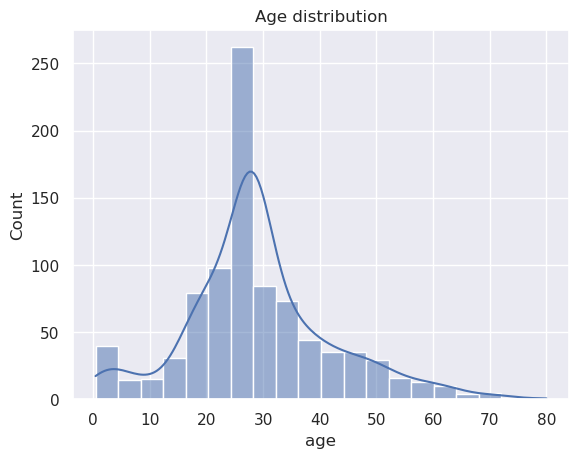

In [84]:
sns.histplot(data=data, x="age", bins=20, kde=True)
plt.title("Age distribution")
plt.show()

**`countplot`** — counts per category, split by another (`hue`).

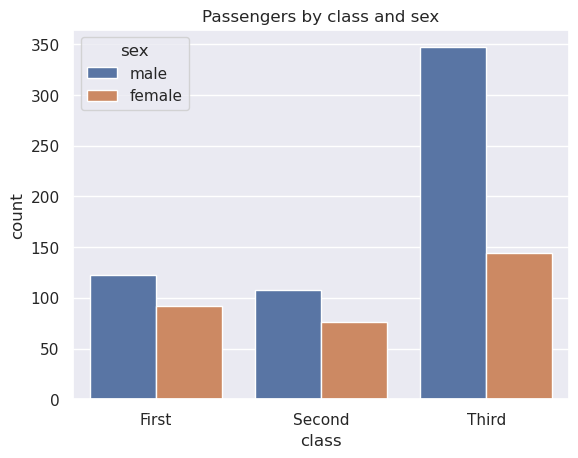

In [85]:
sns.countplot(data=data, x="class", hue="sex")
plt.title("Passengers by class and sex")
plt.show()

**`boxplot`** — spread and outliers of a number across groups.

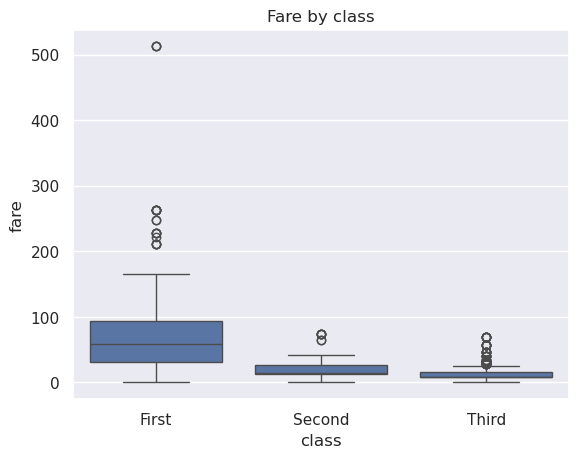

In [86]:
sns.boxplot(data=data, x="class", y="fare")
plt.title("Fare by class")
plt.show()

**`scatterplot`** — relationship between two numbers, colored by a third.

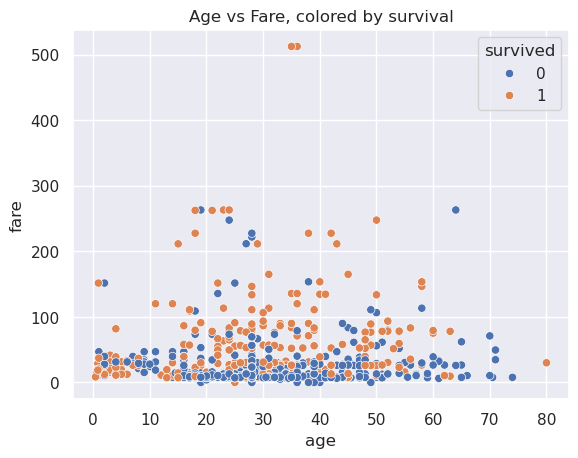

In [87]:
sns.scatterplot(data=data, x="age", y="fare", hue="survived")
plt.title("Age vs Fare, colored by survival")
plt.show()

**`heatmap`** of the correlation matrix — the EDA money shot. Bright/dark cells = strong relationships.

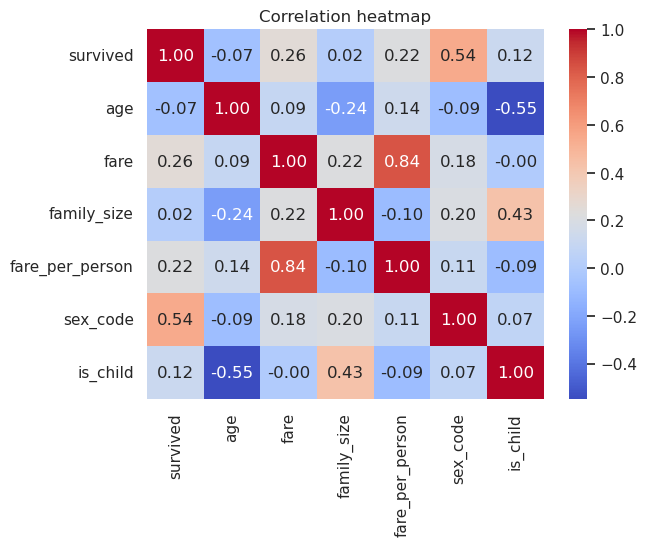

In [88]:
sns.heatmap(data[num_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation heatmap")
plt.show()

**`pairplot`** — every numeric pair at once. *Note:* expensive on wide/large data, so keep it to a few columns.

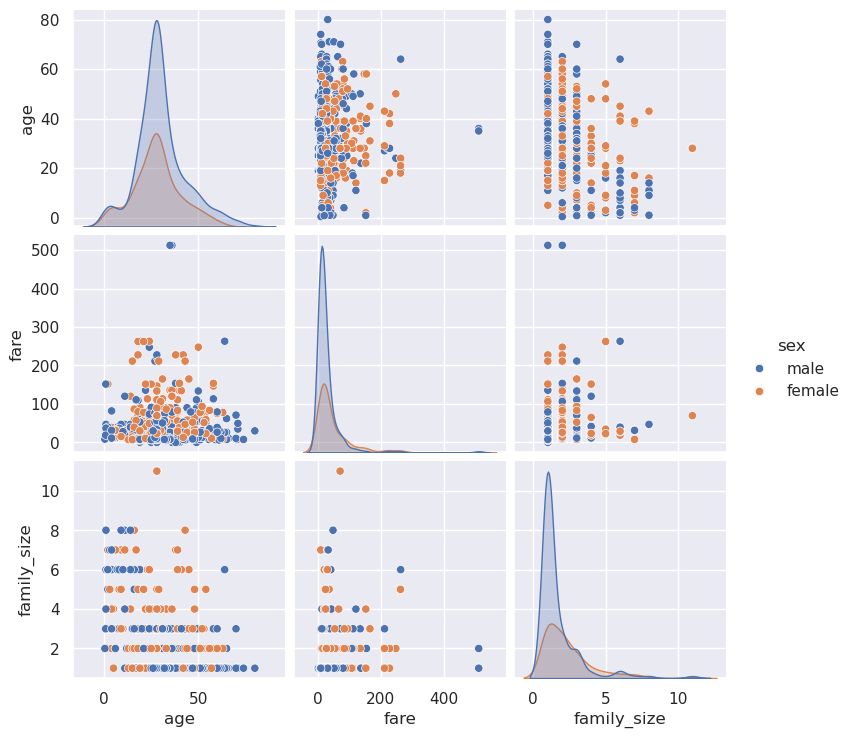

In [97]:
sns.pairplot(data[["age", "fare", "family_size", "sex"]], hue="sex")
plt.show()

### 7b · plotly (interactive)

`pip install plotly` if needed (Colab already has it). These charts let you **hover and zoom**.

In [90]:
import plotly.express as px

px.histogram(data, x="age", color="sex",
             title="Age distribution by sex (hover me)")

In [91]:
px.box(data, x="class", y="fare", color="sex",
       title="Fare by class and sex")

In [92]:
px.scatter(data, x="age", y="fare", color="survived",
           hover_data=["class", "who"],
           title="Age vs Fare (interactive)")

For a bar chart of a *computed* stat, build the small summary frame first, then plot it:

In [93]:
surv_by_class = data.groupby("class")["survived"].mean().reset_index()
px.bar(surv_by_class, x="class", y="survived",
       title="Survival rate by class")

/tmp/ipykernel_35780/3185517287.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  surv_by_class = data.groupby("class")["survived"].mean().reset_index()


---
## 8 · Close the loop — hand off to a model

A model eats a **numeric table** of features (`X`) and a **target** column (`y`). Everything above was getting us here.

In [94]:
# X = the feature columns (all numeric / encoded now); y = what we predict
feature_cols = ["age", "fare", "family_size", "fare_per_person", "sex_code", "is_child"]
X = data[feature_cols]
y = data["survived"]

print("X shape (rows, features):", X.shape)
print("y shape:", y.shape)
print()
print("As a numpy array (what the model actually sees):")
print(X.to_numpy()[:3])    # .to_numpy() is the pandas -> numpy bridge

X shape (rows, features): (889, 6)
y shape: (889,)

As a numpy array (what the model actually sees):
[[22.       7.25     2.       3.625    0.       0.     ]
 [38.      71.2833   2.      35.64165  1.       0.     ]
 [26.       7.925    1.       7.925    1.       0.     ]]


That `(X, y)` pair is the input to scikit-learn (`model.fit(X, y)`) or a neural net. **Your Deep Learning course picks up exactly here** — same arrays, same shapes, just with gradients flowing through them.

---
## Cheat sheet — verbs by pipeline stage

| Stage | Go-to moves |
|---|---|
| **NumPy** | `np.array` · `reshape` · `M[mask]` · `a*2` (vectorize) · `.sum(axis=0/1)` |
| **Load** | `pd.read_csv` · `sns.load_dataset` |
| **Look** | `.head()` · `.info()` · `.describe()` · `.value_counts()` · `.dtypes` |
| **Select** | `df["c"]` · `.loc[]` · `.iloc[]` · `df[df["c"] > x]` · `.isin()` |
| **Clean** | `.isnull().sum()` · `.dropna()` · `.fillna(median/mode/"Unknown")` |
| **Transform** | new cols from math · `.astype()` · `.map()` · `pd.cut()` · `.apply()` · `.str` |
| **Aggregate** | `.groupby().mean()` · `.agg([...])` · `pivot_table` · `.sort_values()` · `.corr()` |
| **Plot** | seaborn: `histplot/countplot/boxplot/scatterplot/heatmap` · plotly: `px.histogram/box/scatter/bar` |
| **Hand off** | `X = data[cols]` · `y = data[target]` · `X.to_numpy()` |

---
**Make it stick (do this now, ~15 min):** pick **one** stage above, run `df = sns.load_dataset("tips")`, and redo that stage on the new data. Different dataset, same verbs — that's the rep that turns reading into knowing. You've got this.